# EXXA — Conditional DDPM Denoising (Kaggle)

Week-4 diffusion model for denoising protoplanetary-disk observations, run on Kaggle's GPU.

**Pipeline:** clone the fork for code (`src/`) → load data from a Kaggle Dataset →
train the scaled `DiffusionUNet` (ch=64, 4 levels, ~17.2M params) as a conditional DDPM
→ DDIM-evaluate PSNR/SSIM/MSE → visualise.

## Before you run
1. **Enable GPU**: Settings → Accelerator → *GPU T4 x1* (or P100).
2. **Enable Internet**: Settings → Internet → *On* (needed to clone the repo + pip install).
3. **Attach the data**: upload `dirty.npy` and `clean.npy` as a Kaggle Dataset, then
   *Add Input* → your dataset. The notebook auto-discovers it under `/kaggle/input/`.


## 1. Setup — clone fork, install deps, set import path


In [1]:
import os, sys, subprocess

REPO_URL  = "https://github.com/KrishanYadav333/EXXA.git"
REPO_DIR  = "/kaggle/working/EXXA"
PKG_ROOT  = os.path.join(REPO_DIR, "DENOISING_DIFFUSION")  # contains src/
BRANCH    = "week-4"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git","clone","--branch",BRANCH,"--depth","1",REPO_URL,REPO_DIR], check=True)
else:
    print("repo already cloned")

# pytorch-msssim for the SSIM metric
subprocess.run([sys.executable,"-m","pip","install","-q","pytorch-msssim"], check=True)

if PKG_ROOT not in sys.path:
    sys.path.insert(0, PKG_ROOT)
print("import root:", PKG_ROOT)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5029/5029), done.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 79.7 MB/s eta 0:00:00
import root: /kaggle/working/EXXA/DENOISING_DIFFUSION


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 2. Imports & device


In [2]:
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data.dataset import create_dataloaders
from src.models.diffusion_unet import default_diffusion_config, DiffusionUNet
from src.training.diffusion import DenoisingDiffusion

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "|", torch.cuda.get_device_name(0) if device=="cuda" else "")

device: cuda | Tesla T4


## 3. Locate & load data

Auto-discovers `dirty.npy` / `clean.npy` anywhere under `/kaggle/input/`.
Both arrays are `(975, 600, 600)` in `[0, 1]`.


In [3]:
def find_data():
    hits = glob.glob('/kaggle/input/**/dirty.npy', recursive=True)
    if hits:
        return os.path.dirname(hits[0])
    if os.path.exists('data/dirty.npy'):   # local fallback
        return 'data'
    raise FileNotFoundError('Upload dirty.npy/clean.npy as a Kaggle Dataset and Add Input.')

DATA_DIR = find_data()
print('data dir:', DATA_DIR)

dirty = np.load(os.path.join(DATA_DIR,'dirty.npy')).astype(np.float32)
clean = np.load(os.path.join(DATA_DIR,'clean.npy')).astype(np.float32)
print('dirty', dirty.shape, 'clean', clean.shape,
      '| range [%.3f, %.3f]' % (dirty.min(), dirty.max()))

d_tr, d_val, c_tr, c_val = train_test_split(dirty, clean, test_size=0.2, random_state=42, shuffle=True)
print('train', d_tr.shape[0], 'val', d_val.shape[0])

data dir: /kaggle/input/datasets/krishanyadav333/exxa-dataset
dirty (975, 600, 600) clean (975, 600, 600) | range [0.000, 1.000]
train 780 val 195


## 4. Patch loaders

64x64 random patches, `[dirty, clean]` channel pairs. On a 16 GB Kaggle GPU we can
afford a larger effective batch than the local 4 GB card.


In [4]:
BATCH_IMAGES = 8     # images per batch
PATCH_N      = 4     # random patches per image  ->  effective batch = 32 patches
PATCH_SIZE   = 64

train_loader, val_loader = create_dataloaders(
    dirty_train=d_tr, clean_train=c_tr,
    dirty_val=d_val,  clean_val=c_val,
    batch_size=BATCH_IMAGES, num_workers=0,
    parse_patches=True, patch_size=PATCH_SIZE, n_patches=PATCH_N,
)
print('train batches', len(train_loader), '| val batches', len(val_loader))

train batches 98 | val batches 25


## 5. Model & diffusion runner

Scaled config: `ch=64`, `ch_mult=[1,2,2,4]` (4 levels), attention @16x16, ~17.2M params.

> To use the 16 GB headroom for a bigger model, bump `cfg.model.ch` to 128 and/or
> extend `cfg.model.ch_mult` (e.g. `[1,2,3,4]`), then lower `BATCH_IMAGES` if needed.


In [5]:
cfg = default_diffusion_config(image_size=PATCH_SIZE)
# cfg.model.ch = 128          # <- uncomment to scale up on the bigger GPU
# cfg.model.ch_mult = [1,2,3,4]

diffusion = DenoisingDiffusion(
    config=cfg, device=device, lr=2e-5,
    checkpoint_path='/kaggle/working/diffusion_best.pth.tar',
)
n_params = sum(p.numel() for p in diffusion.model.parameters())
print(f'DiffusionUNet params: {n_params:,}')

DiffusionUNet params: 17,216,193


## 6. Train

Diffusion models need **many** steps to sample well — the local 40-epoch / ~6.4k-step run
produced a weak sampler (SSIM ~0.23). Train substantially longer here (Kaggle is far faster).


In [6]:
EPOCHS = 100     

results = diffusion.train(train_loader, val_loader, n_epochs=EPOCHS)
print('\nbest val loss:', round(results['best_val_loss'], 4))

Conditional DDPM training
  params : 17,216,193
  device : cuda (DataParallel x2), timesteps: 1000
[epoch   1/100] train 990.0310 | val 280.7660  *best  (26.5s)
[epoch   2/100] train 236.0068 | val 190.8818  *best  (25.1s)
[epoch   3/100] train 166.5433 | val 141.5058  *best  (25.9s)
[epoch   4/100] train 125.7204 | val 95.4097  *best  (27.6s)
[epoch   5/100] train 100.8531 | val 79.9399  *best  (27.2s)
[epoch   6/100] train 84.5395 | val 80.8064  (26.0s)
[epoch   7/100] train 70.9348 | val 52.6900  *best  (27.0s)
[epoch   8/100] train 60.4399 | val 64.5276  (26.6s)
[epoch   9/100] train 56.4152 | val 48.4145  *best  (27.0s)
[epoch  10/100] train 56.0267 | val 64.6797  (26.4s)
[epoch  11/100] train 56.1920 | val 51.7797  (26.4s)
[epoch  12/100] train 52.1612 | val 47.9399  *best  (27.1s)
[epoch  13/100] train 42.0267 | val 43.1180  *best  (27.0s)
[epoch  14/100] train 44.8444 | val 58.5508  (26.2s)
[epoch  15/100] train 45.3378 | val 30.1680  *best  (26.9s)
[epoch  16/100] train 49.443

## 7. Loss curve


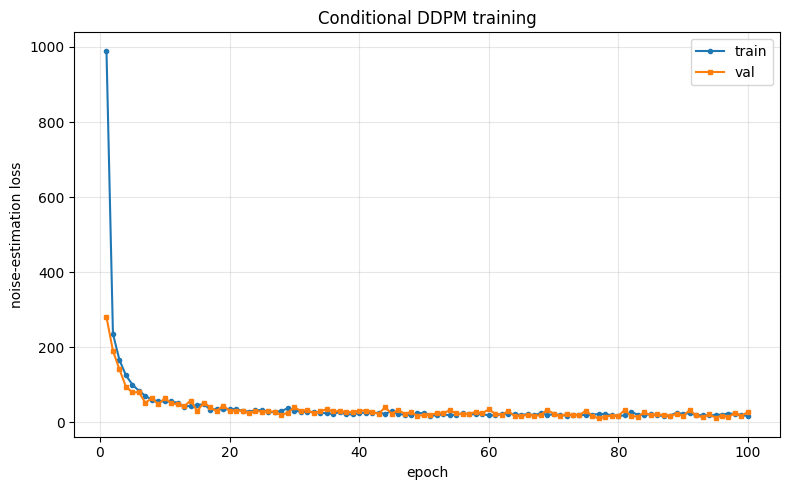

In [7]:
tr, va = results['train_losses'], results['val_losses']
plt.figure(figsize=(8,5))
plt.plot(range(1,len(tr)+1), tr, marker='o', ms=3, label='train')
plt.plot(range(1,len(va)+1), va, marker='s', ms=3, label='val')
plt.xlabel('epoch'); plt.ylabel('noise-estimation loss')
plt.title('Conditional DDPM training'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/diffusion_loss.png', dpi=130); plt.show()

## 8. DDIM evaluation

Loads the best (EMA) checkpoint and denoises validation patches with 25 DDIM steps,
reporting PSNR / SSIM / MSE in `[0, 1]` (SSIM is the key metric for disk structure).


In [8]:
diffusion.load_checkpoint('/kaggle/working/diffusion_best.pth.tar')
metrics = diffusion.evaluate(val_loader, sampling_timesteps=25, max_batches=12, use_ema=True)
print(f"n={metrics['n']}  PSNR={metrics['psnr']:.4f} dB  "
      f"SSIM={metrics['ssim']:.4f}  MSE={metrics['mse']:.6f}")

=> loaded '/kaggle/working/diffusion_best.pth.tar' (epoch 77, step 7546)
n=384  PSNR=14.5900 dB  SSIM=0.2207  MSE=0.286854


### Reference baselines (same val protocol, ranked by SSIM)

| Method | PSNR | SSIM | MSE |
|---|---|---|---|
| AE HybridLoss | 19.92 | **0.7609** | 0.013920 |
| VAE (MSE+SSIM+KL) | 20.00 | 0.7059 | 0.013336 |
| U-Net HybridLoss | 20.63 | 0.7044 | 0.011653 |
| Gaussian σ=2 | 22.78 | 0.4230 | 0.006380 |
| DDPM (local, 40 ep) | 14.75 | 0.2348 | 0.305799 |

Goal for the Kaggle run: push the DDPM SSIM up toward / past the regression baselines.


## 9. Visualise: dirty → DDPM-denoised → clean


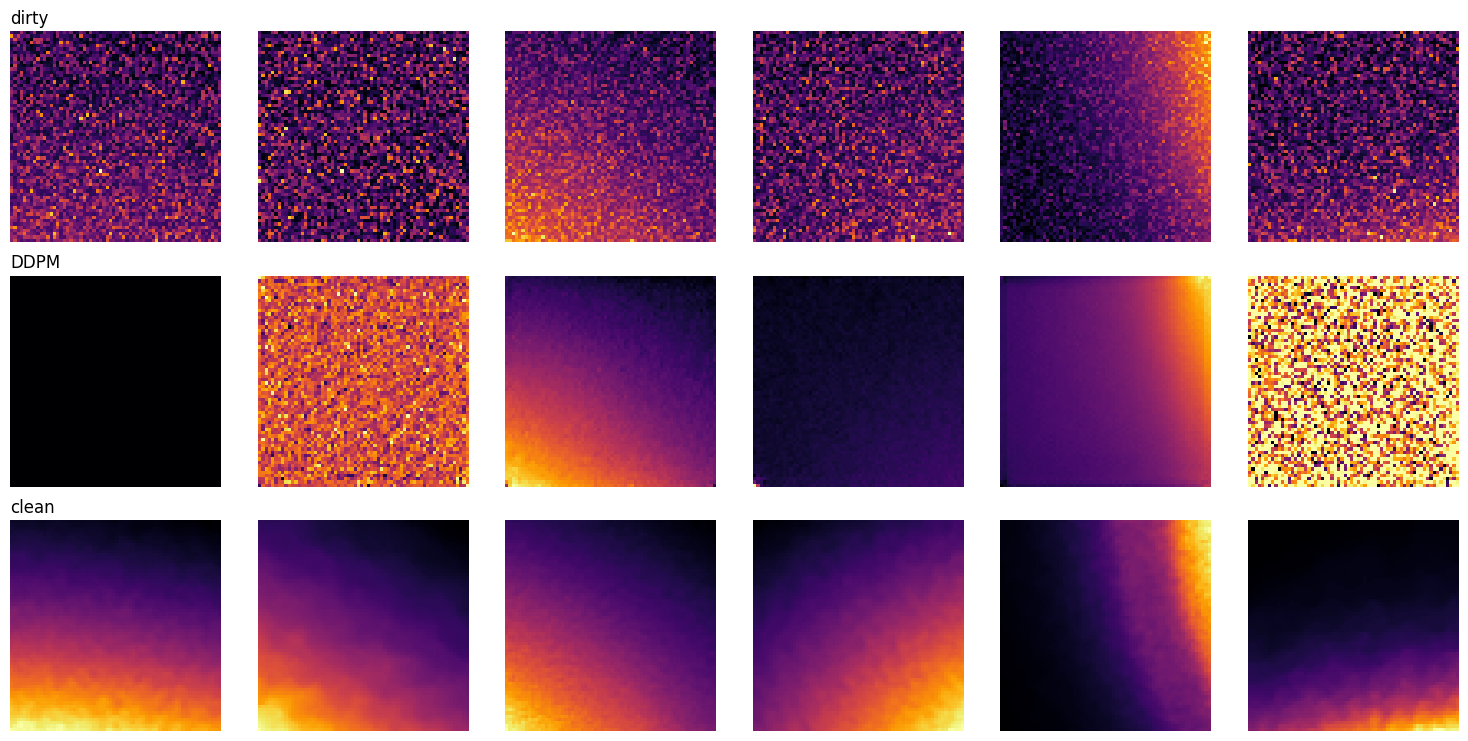

In [9]:
x, _ = next(iter(val_loader))
x = x.flatten(0,1) if x.ndim==5 else x
dirty_p = x[:6, 0:1].clamp(0,1)
clean_p = x[:6, 1:2].clamp(0,1)
pred_p  = diffusion.sample(dirty_p, sampling_timesteps=25, use_ema=True).cpu()

fig, ax = plt.subplots(3, 6, figsize=(15, 7.5))
rows = [(dirty_p,'dirty'), (pred_p,'DDPM'), (clean_p,'clean')]
for i,(img,name) in enumerate(rows):
    for j in range(6):
        ax[i,j].imshow(img[j,0], cmap='inferno'); ax[i,j].axis('off')
    ax[i,0].set_title(name, loc='left', fontsize=12)
plt.tight_layout(); plt.savefig('/kaggle/working/diffusion_samples.png', dpi=130); plt.show()

## 10. Outputs

Saved to `/kaggle/working/` (downloadable from the notebook's *Output* tab):
- `diffusion_best.pth.tar` — best checkpoint (model + EMA + optimizer + config)
- `diffusion_loss.png` — training curves
- `diffusion_samples.png` — qualitative comparison
